<a href="https://colab.research.google.com/github/ShaojieDong503/HAD5016-Datathon-4/blob/main/datathon_4_LSTM_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IN_DIR = '/content/drive/My Drive/ML_Datathon/Datathon_4'
in_file = "Datathon #4 - mhealth Dataset - HAD7001.csv"

In [ ]:
import os
import re
import io
import numpy as np
import pandas as pd

in_path = os.path.join(IN_DIR, in_file)
df = pd.read_csv(in_path)

In [ ]:

from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

import matplotlib.pyplot as plt

In [ ]:
def Create_ID_column_for_participant_and_activity(df, participant_ID:str, activity:str, count_col='activity_participant_ID'):
    """
    This function assigns a unique identifier to each participant-activity sequence in the dataframe.
    Every time a participant switches activities, a new ID is assigned in the specified column.

    This assumes that the data is in chronological order and accounts for cases where a participant
    engages in multiple activities over time (e.g., switching from activity 0 to activity 1, back to 0,
    and then to activity 2). Each transition triggers a new ID to be created, aiding in grouping and
    sequence generation.

    Parameters:
        df (pd.DataFrame): The input dataframe.
        participant_ID (str): Column name representing the participant identifier.
        activity (str): Column name representing the activity label.
        count_col (str, optional): Name of the new column to store sequence IDs. Default is 'activity_participant_ID'.

    Returns:
        pd.DataFrame: The dataframe with an added column assigning unique sequence IDs.
    """
    df[count_col] = 0  # initialize the new ID column with 0

    # initialize variables to store last values
    last_subject = None
    last_activity = None
    count = 0

    # loop through the rows of the df
    for index, row in df.iterrows():
        current_subject = row[participant_ID]
        current_activity = row[activity]

        # check if the values are the same as the last row
        if current_subject == last_subject and current_activity == last_activity:
            df.at[index, count_col] = count
        else:
            count += 1
            df.at[index, count_col] = count

        # update the last values
        last_subject = current_subject
        last_activity = current_activity

    return df

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

feature_cols = [
    "alx", "aly", "alz",
    "glx", "gly", "glz",
    "arx", "ary", "arz",
    "grx", "gry", "grz"
]

target_col = "Activity"
subject_col = "subject"
seq_id_col = "activity_participant_ID"

val_subjects = ["subject7"]
test_subjects = ["subject8", "subject9"]

BATCH_SIZE = 64
NUM_EPOCHS = 80
PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MIN_SEQ_LEN = 10   # drop extremely short sequences

Using device: cuda


In [ ]:
df = df.copy()

df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
df.columns = [str(c).strip() for c in df.columns]

required_cols = feature_cols + [target_col, subject_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df[subject_col] = df[subject_col].astype(str).str.strip()

df = df.dropna(subset=feature_cols + [target_col, subject_col]).copy()
df = df.drop_duplicates().copy()

# preserve row order as time order proxy
df = df.reset_index(drop=False).rename(columns={"index": "orig_idx"})
df = df.sort_values([subject_col, "orig_idx"]).reset_index(drop=True)

# use your exact function
df = Create_ID_column_for_participant_and_activity(
    df,
    participant_ID=subject_col,
    activity=target_col,
    count_col=seq_id_col
)

print("Cleaned shape:", df.shape)
print(df[[subject_col, target_col, seq_id_col]].head(20))
print("Number of contiguous sequences:", df[seq_id_col].nunique())

Cleaned shape: (999999, 16)
     subject  Activity  activity_participant_ID
0   subject1         0                        1
1   subject1         0                        1
2   subject1         0                        1
3   subject1         0                        1
4   subject1         0                        1
5   subject1         0                        1
6   subject1         0                        1
7   subject1         0                        1
8   subject1         0                        1
9   subject1         0                        1
10  subject1         0                        1
11  subject1         0                        1
12  subject1         0                        1
13  subject1         0                        1
14  subject1         0                        1
15  subject1         0                        1
16  subject1         0                        1
17  subject1         0                        1
18  subject1         0                        1
19  subject1

In [ ]:
all_subjects = sorted(df[subject_col].unique())
train_subjects = [s for s in all_subjects if s not in val_subjects + test_subjects]

train_df = df[df[subject_col].isin(train_subjects)].copy()
val_df   = df[df[subject_col].isin(val_subjects)].copy()
test_df  = df[df[subject_col].isin(test_subjects)].copy()

print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Test subjects:", test_subjects)

Train subjects: ['subject1', 'subject2', 'subject3', 'subject4', 'subject5', 'subject6']
Val subjects: ['subject7']
Test subjects: ['subject8', 'subject9']


In [ ]:
def build_full_sequences(df_in, feature_cols, target_col, subject_col, seq_id_col, min_seq_len=10):
    sequences = []
    labels = []
    lengths = []
    metadata = []

    grouped = df_in.groupby(seq_id_col, sort=False)

    for seq_id, g in grouped:
        g = g.sort_values("orig_idx").reset_index(drop=True)

        seq_len = len(g)
        if seq_len < min_seq_len:
            continue

        if g[target_col].nunique() != 1:
            continue

        X_seq = g[feature_cols].to_numpy(dtype=np.float32)
        y_seq = int(g[target_col].iloc[0])
        subj = g[subject_col].iloc[0]

        sequences.append(torch.tensor(X_seq, dtype=torch.float32))
        labels.append(y_seq)
        lengths.append(seq_len)
        metadata.append({
            "sequence_id": seq_id,
            "subject": subj,
            "label": y_seq,
            "length": seq_len
        })

    return sequences, np.array(labels, dtype=np.int64), np.array(lengths), pd.DataFrame(metadata)

In [ ]:
train_sequences, y_train, len_train, meta_train = build_full_sequences(
    train_df, feature_cols, target_col, subject_col, seq_id_col, min_seq_len=MIN_SEQ_LEN
)

val_sequences, y_val, len_val, meta_val = build_full_sequences(
    val_df, feature_cols, target_col, subject_col, seq_id_col, min_seq_len=MIN_SEQ_LEN
)

test_sequences, y_test, len_test, meta_test = build_full_sequences(
    test_df, feature_cols, target_col, subject_col, seq_id_col, min_seq_len=MIN_SEQ_LEN
)

print("Train sequences:", len(train_sequences), Counter(y_train))
print("Val sequences:  ", len(val_sequences), Counter(y_val))
print("Test sequences: ", len(test_sequences), Counter(y_test))

print(meta_train["length"].describe())

Train sequences: 150 Counter({np.int64(0): 78, np.int64(1): 6, np.int64(2): 6, np.int64(3): 6, np.int64(4): 6, np.int64(6): 6, np.int64(7): 6, np.int64(8): 6, np.int64(9): 6, np.int64(10): 6, np.int64(11): 6, np.int64(12): 6, np.int64(5): 6})
Val sequences:   35 Counter({np.int64(0): 18, np.int64(5): 6, np.int64(1): 1, np.int64(2): 1, np.int64(3): 1, np.int64(4): 1, np.int64(6): 1, np.int64(7): 1, np.int64(8): 1, np.int64(9): 1, np.int64(10): 1, np.int64(11): 1, np.int64(12): 1})
Test sequences:  31 Counter({np.int64(0): 16, np.int64(1): 2, np.int64(2): 2, np.int64(5): 2, np.int64(3): 1, np.int64(4): 1, np.int64(6): 1, np.int64(7): 1, np.int64(8): 1, np.int64(9): 1, np.int64(10): 1, np.int64(11): 1, np.int64(12): 1})
count      150.000000
mean      4992.006667
std       6256.498151
min       1024.000000
25%       3072.000000
50%       3072.000000
75%       4608.000000
max      42701.000000
Name: length, dtype: float64


In [ ]:
class FullSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

def collate_fn(batch):
    sequences, labels = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0.0)
    labels = torch.tensor(labels, dtype=torch.long)

    return padded_sequences, lengths, labels

In [ ]:
train_dataset = FullSequenceDataset(train_sequences, y_train)
val_dataset   = FullSequenceDataset(val_sequences, y_val)
test_dataset  = FullSequenceDataset(test_sequences, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [ ]:
num_classes = len(np.unique(y_train))
n_features = len(feature_cols)

class FullSequenceLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, num_classes=3, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, lengths):
        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hn, cn) = self.lstm(packed)
        last_hidden = hn[-1]
        logits = self.classifier(last_hidden)
        return logits

model = FullSequenceLSTM(
    input_size=n_features,
    hidden_size=32,
    num_layers=1,
    num_classes=num_classes,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(model)

FullSequenceLSTM(
  (lstm): LSTM(12, 32, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=13, bias=True)
  )
)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, lengths, y_batch in loader:
        X_batch = X_batch.to(device)
        lengths = lengths.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, lengths, y_batch in loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch, lengths)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                num_epochs=40, patience=5):
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [ ]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE
)

Epoch 01/80 | Train Loss: 2.5723 | Train Acc: 0.0333 | Val Loss: 2.5239 | Val Acc: 0.1714
Epoch 02/80 | Train Loss: 2.5558 | Train Acc: 0.0467 | Val Loss: 2.5113 | Val Acc: 0.1714
Epoch 03/80 | Train Loss: 2.5358 | Train Acc: 0.0467 | Val Loss: 2.4994 | Val Acc: 0.1714
Epoch 04/80 | Train Loss: 2.5308 | Train Acc: 0.0600 | Val Loss: 2.4875 | Val Acc: 0.1714
Epoch 05/80 | Train Loss: 2.5095 | Train Acc: 0.0867 | Val Loss: 2.4749 | Val Acc: 0.1714
Epoch 06/80 | Train Loss: 2.4977 | Train Acc: 0.1000 | Val Loss: 2.4620 | Val Acc: 0.2571
Epoch 07/80 | Train Loss: 2.4775 | Train Acc: 0.2267 | Val Loss: 2.4488 | Val Acc: 0.3714
Epoch 08/80 | Train Loss: 2.4785 | Train Acc: 0.2000 | Val Loss: 2.4354 | Val Acc: 0.3143
Epoch 09/80 | Train Loss: 2.4643 | Train Acc: 0.3067 | Val Loss: 2.4213 | Val Acc: 0.4000
Epoch 10/80 | Train Loss: 2.4321 | Train Acc: 0.3000 | Val Loss: 2.4068 | Val Acc: 0.4000
Epoch 11/80 | Train Loss: 2.4299 | Train Acc: 0.3467 | Val Loss: 2.3917 | Val Acc: 0.4000
Epoch 12/8

In [ ]:
train_loss, train_acc, y_train_true, y_train_pred = evaluate(model, train_loader, criterion, device)
val_loss, val_acc, y_val_true, y_val_pred = evaluate(model, val_loader, criterion, device)
test_loss, test_acc, y_test_true, y_test_pred = evaluate(model, test_loader, criterion, device)

print("\nFinal metrics")
print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")


Final metrics
Train Loss: 1.6278 | Train Acc: 0.5200
Val   Loss: 1.8263 | Val   Acc: 0.5143
Test  Loss: 1.8197 | Test  Acc: 0.5161


In [ ]:
print("\nTEST CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, digits=4))

print("TEST CONFUSION MATRIX")
print(confusion_matrix(y_test_true, y_test_pred))


TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.5161    1.0000    0.6809        16
           1     0.0000    0.0000    0.0000         2
           2     0.0000    0.0000    0.0000         2
           3     0.0000    0.0000    0.0000         1
           4     0.0000    0.0000    0.0000         1
           5     0.0000    0.0000    0.0000         2
           6     0.0000    0.0000    0.0000         1
           7     0.0000    0.0000    0.0000         1
           8     0.0000    0.0000    0.0000         1
           9     0.0000    0.0000    0.0000         1
          10     0.0000    0.0000    0.0000         1
          11     0.0000    0.0000    0.0000         1
          12     0.0000    0.0000    0.0000         1

    accuracy                         0.5161        31
   macro avg     0.0397    0.0769    0.0524        31
weighted avg     0.2664    0.5161    0.3514        31

TEST CONFUSION MATRIX
[[16  0  0  0  0  0  0  0  0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


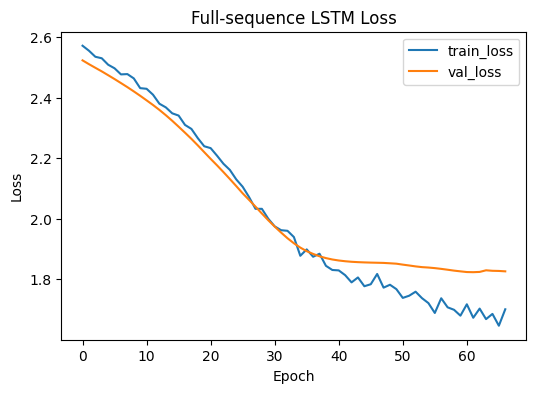

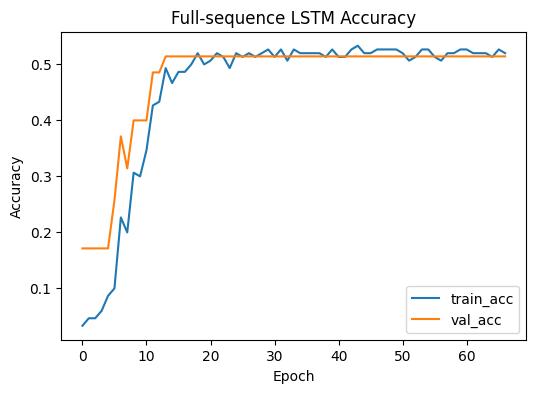

In [ ]:
def plot_history(history, title="Full-sequence LSTM"):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history)

In [ ]:
save_dir = IN_DIR
torch.save(model.state_dict(), f"{save_dir}/full_sequence_lstm_model.pth")
torch.save(model, f"{save_dir}/full_sequence_lstm_full_model.pt")

meta_train.to_csv(f"{save_dir}/meta_train_sequences.csv", index=False)
meta_val.to_csv(f"{save_dir}/meta_val_sequences.csv", index=False)
meta_test.to_csv(f"{save_dir}/meta_test_sequences.csv", index=False)

print("All files saved to:", save_dir)

All files saved to: /content/drive/My Drive/ML_Datathon/Datathon_4
